# M7 — Модель-прогноз 🔮 (експеримент)

Проєкт **«4331 година»** — клімат квартири та відключення світла, Харків.
Це передостанній аналітичний модуль: тут ми не описуємо клімат, а **пробуємо його
передбачити**. Заголовок «експеримент» — свідомий: спец проєкту прямо каже, що
відсутність виграшу проти базового прогнозу — це теж чесний результат.

## Питання

> **Чи можна передбачити температуру в квартирі на 24 години вперед, знаючи вулицю й час?**

Ціль — температура о **t + 24 год**, за ознаками, відомими в момент **t**.
Основна кімната — житлова (єдина з вікном, найважливіша для комфорту людини).
Другий, короткий прогін — комора (кладова), для контрасту.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import model
from src.cleaning import ROOM_COLORS, ROOM_LABELS_UA

ROOT = pathlib.Path.cwd().parent
IMAGES = ROOT / "images"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12})
pd.set_option("display.width", 200)

GREY = "#6C757D"
BEDROOM = ROOM_COLORS["Bedroom"]
PRINTERNYA = ROOM_COLORS["Printernya"]

out = model.run_m7(ROOT)          # уся логіка живе у src/model.py; тут лише виклик
bedroom, printernya, result = out["bedroom"], out["printernya"], out["result"]
pred_df = out["pred_df"]
best_model, best_baseline = out["best_model"], out["best_baseline"]
print("готово")

готово


## Дані

Джерело — `data/clean/hours_wide.csv` (M1): 6 місяців погодинних даних,
`ts` в UTC + `ts_kyiv`. Використовуємо `bedroom_temp`, `printernya_temp`,
`out_temp`, `out_hum`, `out_wind`, `out_cloud`.

**Головне припущення експерименту.** Серед ознак є вулична погода **на момент
цілі** (t+24), а не на момент t. У реальному житті на момент t такої погоди
ми не знаємо — знаємо лише *прогноз* погоди. Тут замість прогнозу підставлена
**фактична** погода з t+24: ми навмисно вдаємо, що маємо ідеальний прогноз
на добу вперед. Це верхня межа того, що взагалі може дати ця ознака —
чесний прогноз погоди був би не точнішим.

**«Застряглий» датчик житлової кімнати** (M1: 144 години 18–24.08 + короткий
епізод 22–23.03, разом 169 год) виключено: ці години перетворені на `NaN`
ще до розрахунку ознак, тому не потрапляють ні в ціль, ні в лаги,
ні в ковзне середнє. У коморі застряглих годин немає.

In [2]:
n_bed_raw = bedroom["wide"]["bedroom_temp"].notna().sum()
print(f"годин у hours_wide загалом      : {len(bedroom['wide']):,}")
print(f"з них bedroom_temp не NaN       : {n_bed_raw:,}")
print(f"рядків після ознак і виключення "
      f"застряглих (train+test)         : {len(bedroom['supervised']):,}")

годин у hours_wide загалом      : 4,402
з них bedroom_temp не NaN       : 4,323
рядків після ознак і виключення застряглих (train+test)         : 3,628


## Ознаки

14 ознак, усі відомі в момент **t** (для вулиці — це фактична погода моменту
**t+24**, див. припущення вище).

In [3]:
WHEN_UA = {
    "room_temp_t": "зараз (t)", "lag_1h": "зараз (t)", "lag_3h": "зараз (t)",
    "lag_6h": "зараз (t)", "lag_12h": "зараз (t)", "lag_24h": "зараз (t)",
    "roll24_mean": "зараз (t)",
    "out_temp_fcst_t24": "момент цілі t+24 — «ідеальний прогноз»",
    "out_hum_fcst_t24": "момент цілі t+24 — «ідеальний прогноз»",
    "out_wind_fcst_t24": "момент цілі t+24 — «ідеальний прогноз»",
    "out_cloud_fcst_t24": "момент цілі t+24 — «ідеальний прогноз»",
    "hour": "зараз (t) — за 24 год = година цілі", "dow": "зараз (t)", "month": "зараз (t)",
}
feat_tbl = pd.DataFrame([
    {"ознака": c, "що це": model.FEATURE_LABELS_UA[c], "коли відомо": WHEN_UA[c]}
    for c in model.FEATURE_COLS
])
feat_tbl

,ознака,що це,коли відомо
0,room_temp_t,температура зараз,зараз (t)
1,lag_1h,температура 1 год тому,зараз (t)
2,lag_3h,температура 3 год тому,зараз (t)
3,lag_6h,температура 6 год тому,зараз (t)
4,lag_12h,температура 12 год тому,зараз (t)
5,lag_24h,температура 24 год тому (учора),зараз (t)
6,roll24_mean,середнє за останні 24 год,зараз (t)
7,out_temp_fcst_t24,вулична температура (+24 год),момент цілі t+24 — «ідеальний прогноз»
8,out_hum_fcst_t24,вулична вологість (+24 год),момент цілі t+24 — «ідеальний прогноз»
9,out_wind_fcst_t24,вітер (+24 год),момент цілі t+24 — «ідеальний прогноз»


## Поділ train / test

Поділ **за часом, без перемішування**: перші 80 % годин — train, останні 20 % —
test. Чому не випадково: сусідні години сильно автокорельовані (і температура
в кімнаті, і погода) — випадковий поділ дав би тесту рядки, чиї найближчі
сусіди по часу вже в train, модель підглядала б «майбутнє», і MAE на тесті
виглядав би кращим, ніж буде на справді нових даних. Поділ за часом імітує
реальне використання: модель навчена на минулому, перевіряється на
майбутньому, якого не бачила.

In [4]:
print(f"train: {len(bedroom['train']):,} год "
      f"({bedroom['train'].index.min()} … {bedroom['train'].index.max()})")
print(f"test:  {len(bedroom['test']):,} год "
      f"({bedroom['test'].index.min()} … {bedroom['test'].index.max()})")
print(f"test_start = {result['test_start']}")

train: 2,902 год (2026-03-17 08:00:00+00:00 … 2026-08-05 05:00:00+00:00)
test:  726 год (2026-08-05 06:00:00+00:00 … 2026-09-14 17:00:00+00:00)
test_start = 2026-08-05 06:00:00+00:00


## Базові прогнози

| Базовий прогноз | Формула | Ідея |
|---|---|---|
| `persistence` — «як зараз» | T̂(t+24) = T(t) | за добу нічого не зміниться |
| `seasonal_naive` — «як 24 год тому» | T̂(t+24) = T(t−24) | добова циклічність: як було вчора о цій же годині відносно *зараз* |
| `climatology` — середнє за годину доби | T̂(t+24) = mean_train(y \| година(t)) | типова температура для цієї години, без урахування дня |

`seasonal_naive` навмисно бере точку на добу *раніше* за `persistence`
(а не ту саму) — інакше, коли горизонт прогнозу сам дорівнює одній добі,
обидва базові прогнози збіглися б і порівнювати не було б із чим.

## Моделі

1. **Ridge** (лінійна регресія з L2-регуляризацією, `RidgeCV` сам підбирає alpha) —
   ознаки масштабовані (`StandardScaler`).
2. **HistGradientBoostingRegressor** — градієнтний бустинг, ловить нелінійні
   ефекти та взаємодії ознак, які лінійна модель пропускає.

Метрики — **MAE** (середня похибка в °C, легко читати) і **RMSE** (сильніше
штрафує великі промахи).

In [5]:
tbl = bedroom["metrics"].copy()
tbl["метод"] = tbl["method"].map(model.METHOD_LABELS_UA)
tbl = tbl[["метод", "mae", "rmse"]].rename(columns={"mae": "MAE, °C", "rmse": "RMSE, °C"}).round(3)
tbl

,метод,"MAE, °C","RMSE, °C"
0,Gradient Boosting,0.806,1.040
1,Ridge (лінійна регресія),0.918,1.120
2,база: як зараз,1.076,1.385
3,база: середнє за годину доби,1.342,1.605
4,база: як 24 год тому,1.360,1.748


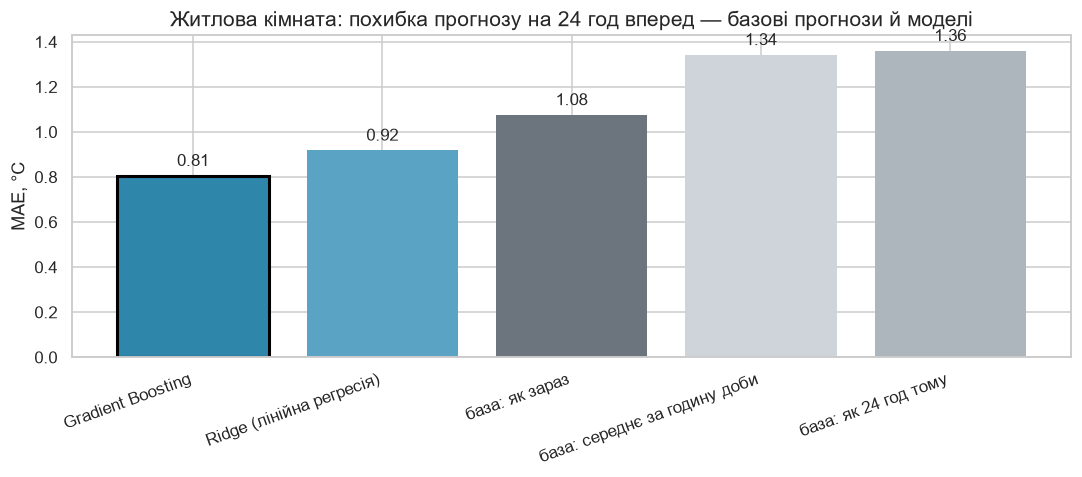

In [6]:
order = bedroom["metrics"].sort_values("mae")
colors = {"persistence": GREY, "seasonal_naive": "#ADB5BD", "climatology": "#CED4DA",
          "ridge": "#5BA3C4", "hgb": BEDROOM}
bar_colors = [colors[m] for m in order["method"]]
edge = ["black" if m == best_model else "none" for m in order["method"]]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar([model.METHOD_LABELS_UA[m] for m in order["method"]], order["mae"],
              color=bar_colors, edgecolor=edge, linewidth=2)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=11)
ax.set_ylabel("MAE, °C")
ax.set_title("Житлова кімната: похибка прогнозу на 24 год вперед — базові прогнози й моделі")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
fig.savefig(IMAGES / "m7_mae_bars.png", dpi=150, bbox_inches="tight")
plt.show()

Обведений чорним стовпець — переможець (**Gradient Boosting**). Обидва базові
прогнози, побудовані на добовій циклічності (`seasonal_naive`, `climatology`),
програють навіть найпростішому `persistence` — у цій квартирі температура
за добу змінюється повільним трендом (пора року, погода), а не за чіткою
добовою хвилею, тож «як зараз» — сильніший орієнтир, ніж «як було вчора».

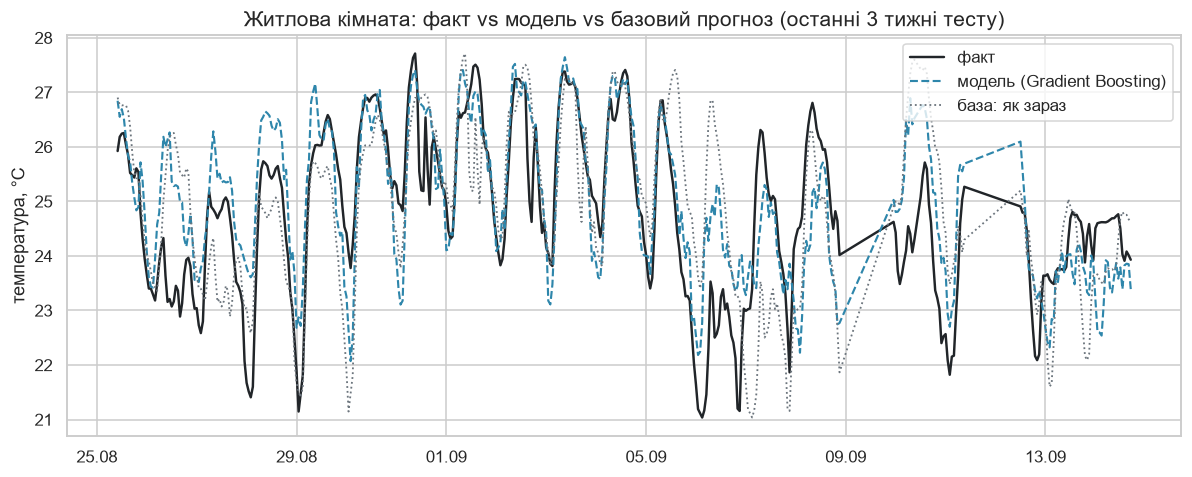

In [7]:
last3w = pred_df[pred_df["ts"] >= pred_df["ts"].max() - pd.Timedelta(days=21)].copy()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(last3w["ts"], last3w["actual"], color="#212529", lw=1.6, label="факт")
ax.plot(last3w["ts"], last3w["pred_best"], color=BEDROOM, lw=1.4, ls="--",
        label=f"модель ({model.METHOD_LABELS_UA[best_model]})")
ax.plot(last3w["ts"], last3w["pred_baseline"], color=GREY, lw=1.2, ls=":",
        label=f"{model.METHOD_LABELS_UA[best_baseline]}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.set_ylabel("температура, °C")
ax.set_title("Житлова кімната: факт vs модель vs базовий прогноз (останні 3 тижні тесту)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(IMAGES / "m7_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

Модель у середньому ближча до факту, ніж базовий прогноз, але не ідеальна:
на різких зламах (швидке похолодання чи потепління) обидва варіанти
відстають — 24 години наперед це важко вгадати, маючи навіть ідеальну погоду.

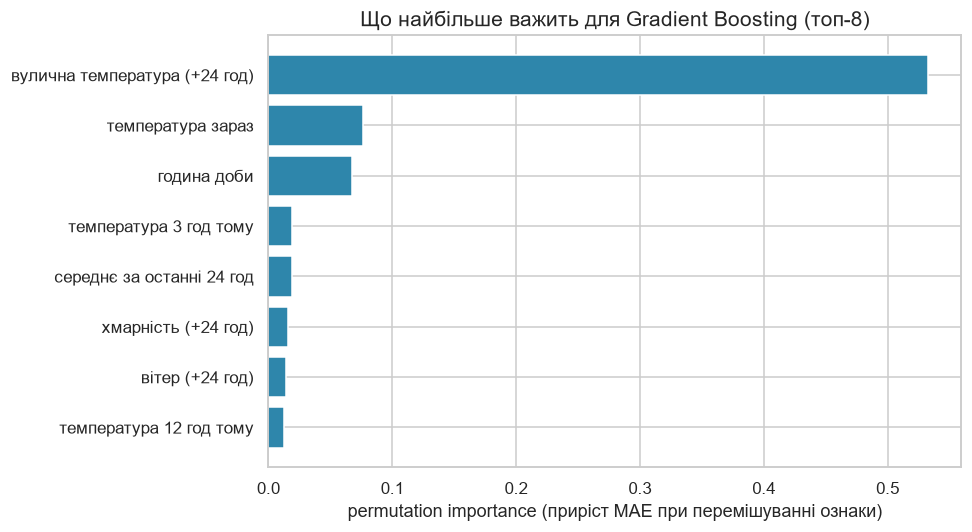

In [8]:
imp = bedroom["importances"].sort_values()
labels = [model.FEATURE_LABELS_UA[f] for f in imp.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, imp.to_numpy(), color=BEDROOM)
ax.set_xlabel("permutation importance (приріст MAE при перемішуванні ознаки)")
ax.set_title("Що найбільше важить для Gradient Boosting (топ-8)")
fig.tight_layout()
fig.savefig(IMAGES / "m7_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Із великим відривом важливіша за все — **вулична температура на момент цілі**
(наше «ідеальне» припущення прогнозу погоди): вона одна дає більшу частину
пояснювальної сили. Далі — поточна температура кімнати й година доби.
Це чесно показує: без хорошого прогнозу погоди в реальному застосуванні
модель втратила б значну частину точності.

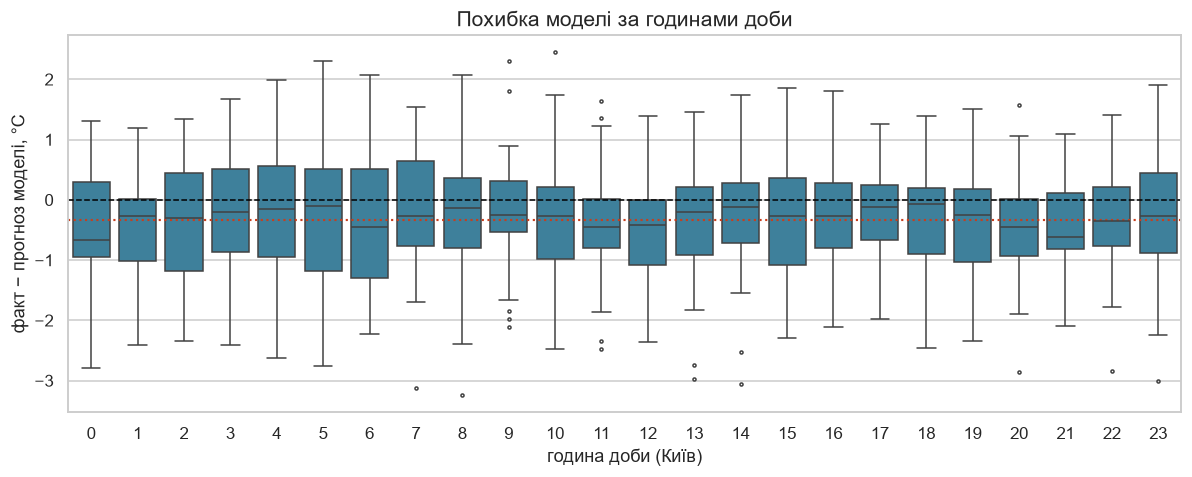

середній резидуал (факт − прогноз): -0.331 °C, медіана: -0.271 °C


In [9]:
res = pred_df.copy()
res["ts"] = pd.to_datetime(res["ts"], utc=True)
res["резидуал"] = res["actual"] - res["pred_best"]
res["година"] = res["ts"].dt.tz_convert("Europe/Kyiv").dt.hour

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=res, x="година", y="резидуал", ax=ax, color=BEDROOM, fliersize=2)
ax.axhline(0, color="black", lw=1, ls="--")
ax.axhline(res["резидуал"].mean(), color="#C73E1D", lw=1.4, ls=":")
ax.set_ylabel("факт − прогноз моделі, °C")
ax.set_xlabel("година доби (Київ)")
ax.set_title("Похибка моделі за годинами доби")
fig.tight_layout()
fig.savefig(IMAGES / "m7_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"середній резидуал (факт − прогноз): {res['резидуал'].mean():.3f} °C, "
      f"медіана: {res['резидуал'].median():.3f} °C")

Форма «ящиків» майже однакова для всіх 24 годин — **прив'язки похибки до
конкретної години доби немає**. Але є інше: пунктирна червона лінія (середнє
= −0,33 °C) лежить нижче нуля майже скрізь — модель **систематично трохи
завищує** прогноз (факт у середньому холодніший за передбачення).
Тестовий період — кінець серпня й вересень, коли надворі стабільно
холоднішає до осені; модель, навчена переважно на весняно-літніх місяцях,
трохи відстає від цього тренду. Розкид (не зсув) трохи ширший вдень,
коли температура рухається найактивніше.

## Чи модель краща за базовий прогноз більш ніж на 0,1 °C?

Проста мова: рахуємо MAE найкращої моделі й MAE найкращого базового прогнозу,
дивимось на різницю.

In [10]:
threshold = 0.1
gain = result["gain_vs_best_baseline_c"]
verdict = "ТАК" if gain > threshold else "НІ"
print(f"найкраща модель       : {model.METHOD_LABELS_UA[best_model]}, MAE = {result['best_mae']:.3f} °C")
print(f"найкращий базовий     : {model.METHOD_LABELS_UA[best_baseline]}, "
      f"MAE = {bedroom['metrics'].set_index('method').loc[best_baseline, 'mae']:.3f} °C")
print(f"виграш моделі         : {gain:.3f} °C")
print(f"виграш > 0,1 °C?      : {verdict}")

найкраща модель       : Gradient Boosting, MAE = 0.806 °C
найкращий базовий     : база: як зараз, MAE = 1.076 °C
виграш моделі         : 0.270 °C
виграш > 0,1 °C?      : ТАК


**Так, для житлової кімнати виграш є** (0,27 °C — це помітно на тлі MAE
базового прогнозу ≈ 1,08 °C, тобто модель точніша приблизно на чверть),
хоч і не революційний. Причина зрозуміла з графіка важливості ознак:
левову частку роботи робить ідеальний прогноз погоди — тобто виграш
переважно від «підказки з майбутнього», а не від складності самої моделі.

## Другий таргет: комора (`printernya_temp`), коротко

Той самий пайплайн, інша кімната: без вікна, зате з постійним теплом від
3D-принтера й NAS (середня температура ≈ 27 °C, спец проєкту це вже
відзначав). Питання: чи так само допомагає погода, коли в кімнаті немає вікна?

In [11]:
tbl2 = printernya["metrics"].copy()
tbl2["метод"] = tbl2["method"].map(model.METHOD_LABELS_UA)
tbl2 = tbl2[["метод", "mae", "rmse"]].rename(columns={"mae": "MAE, °C", "rmse": "RMSE, °C"}).round(3)
tbl2

,метод,"MAE, °C","RMSE, °C"
0,Ridge (лінійна регресія),0.288,0.461
1,база: як зараз,0.319,0.519
2,Gradient Boosting,0.345,0.498
3,база: як 24 год тому,0.399,0.581
4,база: середнє за годину доби,2.487,2.554


**Null-результат для бустингу**: `hgb` (MAE ≈ 0,345 °C) **не перевершує**
`persistence` (MAE ≈ 0,320 °C) — і це чесно написано, а не приховано.
Лінійний Ridge тут трохи кращий за обидва, але різниця мала. Логічно: кімната
без вікна, тепло від техніки стабільне й не залежить від вулиці так сильно,
як у житловій — вуличний «ідеальний прогноз» тут менш корисний.

## Висновки

* Житлова кімната, горизонт 24 год: **Gradient Boosting MAE = 0,81 °C**
  проти **1,08 °C** у найкращого базового прогнозу (`persistence`) —
  виграш **0,27 °C**, більший за поріг 0,1 °C, отже модель має сенс.
* Найважливіша ознака з великим відривом — **вулична температура на момент
  цілі** (перманентна перевага в permutation importance), а це «ідеальний
  прогноз погоди», якого насправді не буває — реальний виграш моделі був би
  скромнішим.
* Обидва базові прогнози, що спираються на добову циклічність
  (`seasonal_naive`, `climatology`), програють простому «як зараз» —
  у цій квартирі температура рухається трендом (сезон, погода), а не чіткою
  добовою хвилею.
* Для комори (`printernya_temp`, без вікна, тепло від техніки) той самий
  бустинг **не** побив `persistence` (0,345 проти 0,320 °C) — чесний
  null-результат: стабільне технічне тепло робить прогноз майже непотрібним.
* Поділ train/test — **строго за часом** (2 902 / 726 год, без
  перемішування), щоб уникнути витоку майбутнього в минуле через
  автокореляцію часових рядів.

## Як сказати на співбесіді за 30 секунд

Я побудувала модель, яка прогнозує температуру в житловій кімнаті на 24
години вперед — за поточними показниками кімнати, лагами й «ідеальним»
прогнозом погоди (навмисне спрощення експерименту, чесно проговорене).
Дані ділила строго за часом, а не випадково, щоб уникнути витоку майбутнього.
Порівняла з трьома базовими прогнозами — «як зараз», «як 24 год тому»,
середнє за годину доби — і Gradient Boosting дав MAE 0,81 °C проти 1,08 °C
у найкращого базового: виграш 0,27 °C, і левову частку цього виграшу дає
саме вулична погода. А для комори без вікна той самий підхід виграшу не
дав — і я написала це прямо, бо чесний null-результат теж результат.